In [3]:
# load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
# load in trade data

df = pd.read_excel("basic_trade_data.xlsx")

In [5]:
# clean col headers
df.columns = df.columns.str.lower().str.replace(" ","_")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   country_code  482 non-null    str  
 1   country       484 non-null    str  
 2   1997          484 non-null    int64
 3   1998          484 non-null    int64
 4   1999          484 non-null    int64
 5   2000          484 non-null    int64
 6   2001          484 non-null    int64
 7   2002          484 non-null    int64
 8   2003          484 non-null    int64
 9   2004          484 non-null    int64
 10  2005          484 non-null    int64
 11  2006          484 non-null    int64
 12  2007          484 non-null    int64
 13  2008          484 non-null    int64
 14  2009          484 non-null    int64
 15  2010          484 non-null    int64
 16  2011          484 non-null    int64
 17  2012          484 non-null    int64
 18  2013          484 non-null    int64
 19  2014          484 non-null    int64
 20 

In [7]:
# transform data from wide to long for plot:

year_cols = [str(y) for y in range(1997, 2026)]

df_long = df.melt(
    id_vars=["country", "country_code", "flow"],
    value_vars=year_cols,
    var_name="year",
    value_name="trade_value"
)

df_long["year"] = df_long["year"].astype(int)


In [8]:
# aggregate data for overall trade (import + exports)

df_overall = (
    df_long
    .groupby(["country", "country_code", "year"], as_index=False)
    .agg(overall_trade=("trade_value", "sum"))
)

df_overall.head()

,country,country_code,year,overall_trade
0,Afghanistan,AF,1997,38
1,Afghanistan,AF,1998,44
2,Afghanistan,AF,1999,34
3,Afghanistan,AF,2000,51
4,Afghanistan,AF,2001,46


In [9]:
# identify top countries in 2025 with trade > £10bn, excluding certain ISO codes

exclude_iso = ["W1", "D5", "B5"]

df_2025_filtered = (
    df_overall[
        (df_overall["year"] == 2025) &                          # keep only 2025
        (df_overall["overall_trade"] > 10000) &        # keep > £10bn
        (~df_overall["country_code"].isin(exclude_iso))         # exclude ISO codes
    ]
    .sort_values("overall_trade", ascending=False)              # order by top value
)

df_2025_filtered

,country,country_code,year,overall_trade
6669,United States inc Puerto Rico,US,2025,331489
2406,Germany,DE,2025,152508
4378,Netherlands,NL,2025,119349
1304,China,CN,2025,104852
2261,France,FR,2025,104289
3073,Ireland,IE,2025,89256
5712,Spain,ES,2025,68301
579,Belgium,BE,2025,59928
3160,Italy,IT,2025,53707
5973,Switzerland,CH,2025,52813


In [11]:
topc = df_2025_filtered.loc[df_2025_filtered["overall_trade"] > 10000, "country"].unique()
topc

<StringArray>
['United States inc Puerto Rico',                       'Germany',
                   'Netherlands',                         'China',
                        'France',                       'Ireland',
                         'Spain',                       'Belgium',
                         'Italy',                   'Switzerland',
                         'India',                        'Norway',
                        'Sweden',                         'Japan',
                        'Poland',                        'Canada',
                     'Hong Kong',                        'Turkey',
                     'Singapore',          'United Arab Emirates',
                     'Australia',                    'Luxembourg',
                       'Denmark',                   'South Korea',
                  'Saudi Arabia',                        'Brazil',
                  'South Africa',                      'Portugal',
                        'Greece',               

In [ ]:
# filter data and create country highlight for plot:

df_plot = df_overall[df_overall["country"].isin(topc)]
highlight = ["Japan", "Australia","Canada"]
df_plot["highlight"] = df_plot["country"].isin(highlight)

C:\Users\tcolw\AppData\Local\Temp\ipykernel_14160\2672644307.py:4: UserWarning: 
The palette list has fewer values (1) than needed (30) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(
C:\Users\tcolw\AppData\Local\Temp\ipykernel_14160\2672644307.py:16: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(


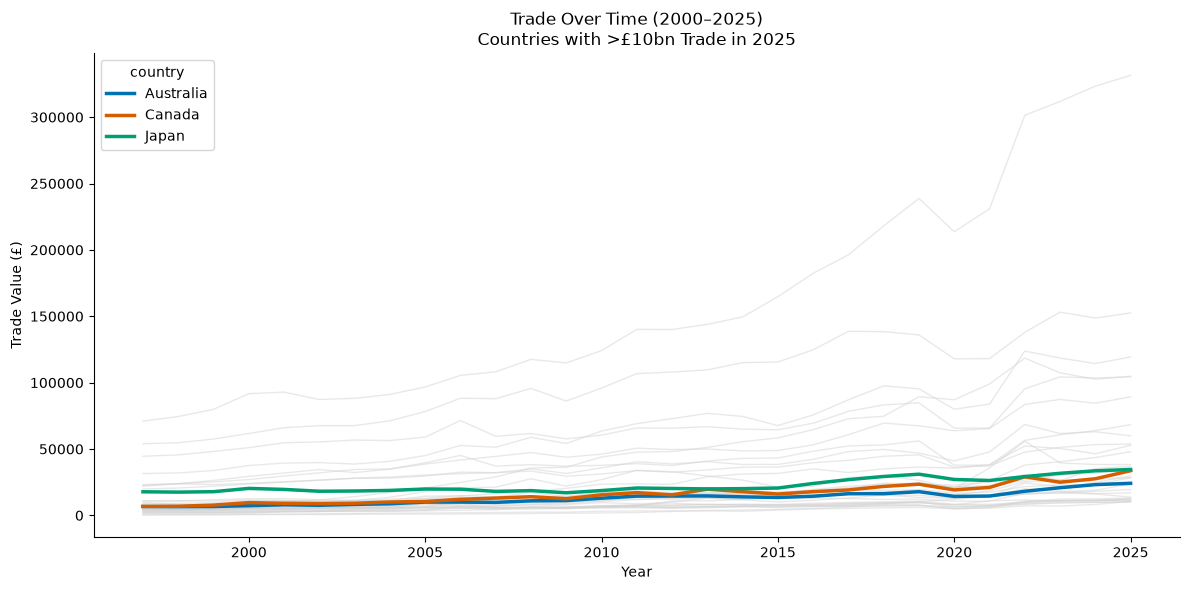

In [15]:
plt.figure(figsize=(12, 6))

# --- Background grey lines ---
sns.lineplot(
    data=df_plot[~df_plot["highlight"]],
    x="year",
    y="overall_trade",
    hue="country",
    palette=["lightgrey"],
    linewidth=1,
    alpha=0.5,
    legend=False
)

# --- Highlighted countries ---
sns.lineplot(
    data=df_plot[df_plot["highlight"]],
    x="year",
    y="overall_trade",
    hue="country",
    palette=["#0072B2", "#D55E00", "#009E73", "#CC79A7"],  # FT-ish colours
    linewidth=2.5
)

plt.title("Trade Over Time (2000–2025)\nCountries with >£10bn Trade in 2025")
plt.xlabel("Year")
plt.ylabel("Trade Value (£)")
sns.despine()
plt.tight_layout()
plt.show()